In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import tqdm
import numpy as np
import pandas as pd

from src.encode import get_canonical_board, uci_to_index
from src.dataclass import ChessDataset
from src.dataset import load_pgn, load_multiple_pgns, create_value_csv_dataset
from src.model import ResNet

In [ ]:
games = load_multiple_pgns(num_pgns=26)

In [ ]:
create_value_csv_dataset(games, name="train")

In [2]:
df = pd.read_csv("data/csv/train.csv")
print(len(df))

2302558


In [8]:
dataset = ChessDataset("data/csv/train.csv")
loader = torch.utils.data.DataLoader(
    dataset, 
    batch_size=256, 
    shuffle=True, 
    num_workers=4,
    pin_memory=True, 
)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet(filters=128, res_blocks=6)
model = model.to(device)

In [5]:
policy_loss = torch.nn.CrossEntropyLoss()
value_loss = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [10]:
# If the model isn't loaded training starts at 0 epochs
epoch = 0

In [11]:
# Step 6: Train the model
EPOCHS = 100
train_losses = []
scaler = torch.GradScaler()

for epoch in tqdm.trange(epoch, EPOCHS):
    model.train()
    total_policy_loss = 0
    total_value_loss = 0

    for boards, labels, values in loader:
        boards = boards.to(device)
        labels = labels.to(device)
        values = values.to(device).float()

        optimizer.zero_grad()

        with torch.autocast(device_type="cuda", dtype=torch.float16):
            policy, value = model(boards)
            p_loss = policy_loss(policy, labels)
            v_loss = value_loss(value.squeeze(), values)

            loss = p_loss + v_loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_policy_loss += p_loss.item()
        total_value_loss += v_loss.item()

    avg_p_loss = total_policy_loss / len(loader)
    avg_v_loss = total_value_loss / len(loader)

    print(f"Epoch {epoch+1}/{EPOCHS+1} - Policy Loss: {avg_p_loss:.4f} - Value Loss: {avg_v_loss:.4f}")

    train_losses.append(avg_p_loss)
    torch.save({
    "train_losses": train_losses,
    }, "data/loss/loss_log.pt")

    
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, f"models/model_1{epoch}.pth")

    print(f"Checkpoint saved at epoch {epoch}")

  1%|          | 1/100 [04:12<6:56:05, 252.18s/it]

Epoch 1/101 - Policy Loss: 1.3940 - Value Loss: 0.3437
Checkpoint saved at epoch 0


  2%|▏         | 2/100 [08:10<6:38:08, 243.76s/it]

Epoch 2/101 - Policy Loss: 1.3835 - Value Loss: 0.3408
Checkpoint saved at epoch 1


  3%|▎         | 3/100 [12:06<6:28:58, 240.60s/it]

...

Epoch 98/101 - Policy Loss: 0.9773 - Value Loss: 0.2910
Checkpoint saved at epoch 97


 99%|█████████▉| 99/100 [6:21:41<03:50, 230.20s/it]

Epoch 99/101 - Policy Loss: 0.9750 - Value Loss: 0.2909
Checkpoint saved at epoch 98


100%|██████████| 100/100 [6:25:32<00:00, 231.33s/it]

Epoch 100/101 - Policy Loss: 0.9732 - Value Loss: 0.2903
Checkpoint saved at epoch 99


In [13]:
import matplotlib.pyplot as plt

# Load the log
loss_log = torch.load(
    "data/loss/loss_log.pt",
    map_location="cpu"
)

In [14]:
train_losses = loss_log["train_losses"]
print(train_losses)
print(len(train_losses))

[1.3940111331637532, 1.3835015595389977, 1.3744987296024385, 1.366518134750082, 1.3589021871194633, 1.3503098861319016, 1.3431469305281245, 1.335600687332323, 1.3277276916328968, 1.3212303168313777, 1.3136857012830356, 1.3070740183569975, 1.3006105202777707, 1.2932850897809145, 1.2869955315531592, 1.2803558454903183, 1.2739487058126377, 1.2680996666688797, 1.2623720286355011, 1.25666141280073, 1.2502233132910503, 1.244151847935041, 1.2384958331355655, 1.232720199156099, 1.2278882906660893, 1.2221147156079788, 1.2168188003383125, 1.2113691132356221, 1.2060185716442429, 1.2012337079109119, 1.196457869738854, 1.190945614066768, 1.1869109870659902, 1.1817120722825822, 1.1771728848006209, 1.1725615957168953, 1.167723759291502, 1.1636768885491091, 1.1593681201065429, 1.1548351765010276, 1.1505694393517907, 1.1470335667699227, 1.1420715030794213, 1.138563919087262, 1.133919132246184, 1.1304554386560357, 1.1262782960285274, 1.1223799416792266, 1.1182232928050764, 1.1149400486887793, 1.11110276

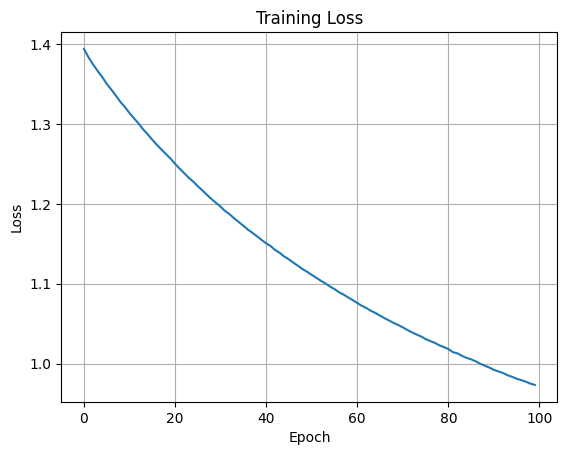

In [15]:
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()